# Othello: R1 conversation behaviour → unaided transfer margin

Continuous version of `othello_data_analysis_2group.ipynb`. **No Solvers/Strugglers split** —
every participant is one row, and the outcome is the signed margin itself.

**DV** — `y` = total final disc margin summed over the two unassisted transfer rounds
(R2 `b220260706` + R3 `bg20260726`). Signed discs; 0 = an even game. Taken from
`scores.csv`, which is the source of truth: the `oth_score_*.json` summaries are missing
for any round that hit the clock, and a round stopped at the buzzer has no final margin
at all, so those participants drop out of every model here.

**Predictors**, all measured on the AI-assisted R1 (`oc20260727`):

| name | what it is |
|---|---|
| `turns` | number of exchanges in `conversation_poc20260727.jsonl` (one line = one user+assistant pair) |
| act shares | % of a participant's R1 turns carrying each dialogue act, from the existing LLM-panel annotations |
| `reasoning` | % of turns carrying any act in `REASONING_ACTS` (the composite the 2-group notebook's OLS used) |
| `genai` | self-reported GenAI usage frequency, ordinal 0–7, from `demographics.json` |
| `r1_margin` | final margin in the assisted R1 game — available as a prior-skill control |

**Read the caveats.** The mandate was 5+ assistant turns, so `turns` is floor-censored and
act *shares* share their denominator with it — expect collinearity, which the VIF check at
the bottom quantifies. n is small and ~8 predictors are screened, so the correlation table
carries a BH-FDR column and everything here is exploratory.

In [23]:
# --- Setup: all imports in one place ---
import csv
import glob
import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [24]:
RECORDINGS_DIR = Path("recordings-download/*/")
RECORDINGS_BASE = Path("recordings-download/")

score_r1 = "oth_score_poc20260727.json"
score_r2 = "oth_score_pb220260706.json"
score_r3 = "oth_score_pbg20260726.json"
conversations = "conversation_poc20260727.jsonl"
annotated = "annotated_conversation_poc20260727.jsonl"

GENAI_USAGE_OPTIONS = {"never": 0, "less_than_monthly": 1, "about_monthly": 2,
                       "few_times_month": 3, "weekly": 4, "few_times_week": 5,
                       "daily": 6, "several_times_day": 7}

# Acts pooled into the `reasoning` composite. Single-act here, matching the 2-group
# notebook's final setting; widen to the three-act version to reproduce its earlier runs.
REASONING_ACTS = ["Think Aloud"]
# REASONING_ACTS = ["Common Ground Question", "Think Aloud", "Knowledge Deficit Question"]

# Manual relabels for acts that don't fit this human<->AI setting (same as the 2-group nb).
ACT_REMAP = {"Correct Answer": "Think Aloud",
             "Social Coordination Action": "Metacomment",
             "Forced Choice": "Metacomment"}

In [25]:
# Participants with both an R1 and an R2 score file on disk (same population as the
# 2-group notebook, before any outcome-based filtering).
all_r1 = {p.split("/")[-2] for p in glob.glob(str(RECORDINGS_DIR / score_r1))}
all_r2 = {p.split("/")[-2] for p in glob.glob(str(RECORDINGS_DIR / score_r2))}
all_candidates = all_r1 & all_r2
print(f"{len(all_candidates)} candidate participants (R1 and R2 scored)")

112 candidate participants (R1 and R2 scored)


## Outcome: summed transfer margin

`y = margin(R2) + margin(R3)`, straight from `scores.csv`. A participant needs **both**
rounds finished — a round stopped by the clock has no final margin — so the count that
drops here is reported below rather than silently imputed.

In [26]:
# --- DV and the R1-margin control, from scores.csv --------------------------------
_rows = list(csv.DictReader(open("scores.csv")))
_by_pid = defaultdict(dict)
for _r in _rows:
    _by_pid[_r["pid"]][_r["round"]] = _r


def _margin(row):
    v = (row or {}).get("margin")
    return float(v) if v not in (None, "") else None


MARGIN, R1_MARGIN = {}, {}
_incomplete = []
for pid, rd in _by_pid.items():
    if "R2" in rd and "R3" in rd:
        m2, m3 = _margin(rd["R2"]), _margin(rd["R3"])
        if m2 is not None and m3 is not None:
            MARGIN[pid] = m2 + m3
        else:
            _incomplete.append(pid)
    m1 = _margin(rd.get("R1"))
    if m1 is not None:
        R1_MARGIN[pid] = m1

_y = np.array(list(MARGIN.values()))
print(f"DV present for {len(MARGIN)} participants "
      f"({len(_incomplete)} had an R2/R3 round end at the buzzer with no final margin)")
print(f"  R2+R3 total margin: mean={_y.mean():+.2f} median={np.median(_y):+.1f} "
      f"sd={_y.std(ddof=1):.2f} range=[{_y.min():+.0f}, {_y.max():+.0f}]")
print(f"  positive (net win across the two rounds): {(_y > 0).sum()}/{len(_y)} = {(_y > 0).mean():.0%}")
print(f"R1 margin present for {len(R1_MARGIN)} participants")

DV present for 108 participants (3 had an R2/R3 round end at the buzzer with no final margin)
  R2+R3 total margin: mean=-13.50 median=-14.0 sd=11.52 range=[-34, +16]
  positive (net win across the two rounds): 16/108 = 15%
R1 margin present for 106 participants


## Predictors

### Dialogue acts

Rebuilds the same tidy LONG frame the 2-group notebook uses (one row per turn × act,
turns with no act kept as a single `utt_type=None` row so they stay in the denominator) —
minus the `outcome` group column, which no longer exists.

In [27]:
def normalize_ann(ann):
    """Canonicalize a stored annotation. Handles both the current dict form and the
    legacy tuple form [consensus, votes, per_model] (serialized as a list) so old
    annotated files don't need re-running."""
    if ann is None:
        return None
    if isinstance(ann, dict):
        return ann
    consensus, votes, per_model = ann                       # legacy list form
    n_valid = sum(v is not None for v in per_model.values())
    confidence = {a: votes[a] / n_valid for a in votes} if n_valid else {}
    no_majority = not consensus and bool(votes)
    final = consensus if consensus else [a for a in votes]  # no-majority -> union
    return {"final": final, "consensus": consensus, "votes": votes,
            "confidence": confidence, "per_model": per_model, "n_valid": n_valid,
            "no_majority": no_majority, "needs_review": no_majority or n_valid < 2,
            "arbiter_used": False}


rows = []
for pid in sorted(all_candidates):
    f = RECORDINGS_BASE / pid / annotated
    if not f.exists():
        continue
    for i, line in enumerate(open(f)):
        turn = json.loads(line)
        ann = normalize_ann(turn.get("annotation_user"))
        acts = [ACT_REMAP.get(a, a) for a in (ann["final"] if ann else [])]
        acts = list(dict.fromkeys(acts))                      # dedup after remap
        conf = {ACT_REMAP.get(k, k): v for k, v in (ann.get("confidence", {}) if ann else {}).items()}
        for act in (acts or [None]):                          # keep unlabelled turns
            rows.append({"pid": pid, "utt": turn.get("user"), "utt_type": act,
                         "conf": conf.get(act) if act else None,
                         "needs_review": bool(ann and ann.get("needs_review")),
                         "utt_ind": i})

df = pd.DataFrame(rows)
print(f"{len(df)} rows | {df['pid'].nunique()} annotated participants | "
      f"{df['needs_review'].mean():.0%} of rows flagged needs_review")
df.head()

887 rows | 112 annotated participants | 3% of rows flagged needs_review


,pid,utt,utt_type,conf,needs_review,utt_ind
0,p786,am i right in thinking that i should choose ed...,Think Aloud,1.000000,False,0
1,p786,am i right in thinking that i should choose ed...,Common Ground Question,1.000000,False,0
2,p786,yes i do try but i find that hard to visualise...,Think Aloud,1.000000,False,1
3,p786,yes i do try but i find that hard to visualise...,Conversational Acknowledgment,0.666667,False,1
4,p786,yes i do try but i find that hard to visualise...,Metacomment,0.666667,False,1


In [28]:
# --- Participant-level design matrix ----------------------------------------------
# Act share = % of a participant's turns carrying that act. Denominator = ALL their
# turns, unlabelled ones included; a turn labelled with the same act twice counts once
# (nunique on the turn index), so each column is a clean "share of turns with this act".
_turns_ann = df.groupby("pid")["utt_ind"].nunique()
_hits = (df.dropna(subset=["utt_type"])
           .groupby(["pid", "utt_type"])["utt_ind"].nunique()
           .unstack(fill_value=0)
           .reindex(_turns_ann.index, fill_value=0))
share = 100 * _hits.div(_turns_ann, axis=0)
ACTS = sorted(share.columns)


def _n_turns(pid):
    """Raw R1 exchange count from the conversation log (not the annotated file)."""
    f = RECORDINGS_BASE / pid / conversations
    return sum(1 for _ in open(f)) if f.exists() else np.nan


def _genai(pid):
    f = RECORDINGS_BASE / pid / "demographics.json"
    v = json.load(open(f)).get("genai_usage") if f.exists() else None
    return float(GENAI_USAGE_OPTIONS.get(v, np.nan))


_reason_hits = (df[df["utt_type"].isin(REASONING_ACTS)]
                  .groupby("pid")["utt_ind"].nunique()
                  .reindex(_turns_ann.index, fill_value=0))

P = pd.DataFrame(index=_turns_ann.index)
P["turns"] = [_n_turns(p) for p in P.index]
P["genai"] = [_genai(p) for p in P.index]
P["reasoning"] = 100 * _reason_hits / _turns_ann
P = P.join(share[ACTS])
P["r1_margin"] = [R1_MARGIN.get(p, np.nan) for p in P.index]
P["y"] = [MARGIN.get(p, np.nan) for p in P.index]

_dropped = int(P["y"].isna().sum())
P = P.dropna(subset=["y"])          # DV is required; covariate gaps are left as NaN
# The `reasoning` composite is dropped from the correlation screen when it collapses to a
# single act already in ACTS -- otherwise it enters the BH family twice as the same test
# and deflates every q. It is still the OLS focal predictor either way.
_dupe = len(REASONING_ACTS) == 1 and REASONING_ACTS[0] in ACTS
PREDICTORS = ["turns", "genai"] + ([] if _dupe else ["reasoning"]) + ACTS
if _dupe:
    print(f"note: `reasoning` == `{REASONING_ACTS[0]}` here, so it is screened once, "
          f"under the act name")

print(f"analysis sample: n={len(P)}  ({_dropped} annotated participants have no complete "
      f"R2+R3 margin)")
print(f"missing covariates: genai {int(P['genai'].isna().sum())}, "
      f"r1_margin {int(P['r1_margin'].isna().sum())}  (dropped per-model, not imputed)")
_mismatch = int((P["turns"] != _turns_ann.reindex(P.index)).sum())
print(f"turns vs annotated-turn count: {_mismatch} participants disagree "
      f"(expect 0; a mismatch means the annotation file is stale)")
P[["turns", "genai", "reasoning", "r1_margin", "y"]].describe().round(2)

note: `reasoning` == `Think Aloud` here, so it is screened once, under the act name
analysis sample: n=108  (4 annotated participants have no complete R2+R3 margin)
missing covariates: genai 0, r1_margin 10  (dropped per-model, not imputed)
turns vs annotated-turn count: 0 participants disagree (expect 0; a mismatch means the annotation file is stale)


,turns,genai,reasoning,r1_margin,y
count,108.00,108.00,108.00,98.00,108.00
mean,5.54,4.40,30.59,-7.71,-13.50
std,1.27,2.03,23.95,16.39,11.52
min,3.00,0.00,0.00,-28.00,-34.00
25%,5.00,3.00,19.17,-20.00,-22.00
50%,5.00,5.00,25.00,-18.00,-14.00
75%,6.00,6.00,40.71,2.00,-8.00
max,10.00,7.00,100.00,18.00,16.00


## Correlations with the summed margin

Pearson (linear, with a Fisher-*z* 95% CI) and Spearman (rank) for each predictor against
`y`. **Spearman is the one to read for `genai`** — it is an ordinal scale, not an interval
one — and it is the safer read for the act shares too, which are bounded and zero-heavy.

`q` is the Benjamini–Hochberg FDR-adjusted Spearman p across the whole screen, so the
multiplicity of testing ~8 predictors is priced in. `n` varies where a covariate is missing.

In [29]:
def _fisher_ci(r, n, alpha=0.05):
    if n < 4 or not np.isfinite(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    lo, hi = z - st.norm.ppf(1 - alpha / 2) * se, z + st.norm.ppf(1 - alpha / 2) * se
    return np.tanh(lo), np.tanh(hi)


res = []
for v in PREDICTORS:
    d = P[[v, "y"]].dropna()
    if len(d) < 4 or d[v].std(ddof=1) == 0:
        res.append({"predictor": v, "n": len(d)})
        continue
    r, rp = st.pearsonr(d[v], d["y"])
    rho, rhop = st.spearmanr(d[v], d["y"])
    lo, hi = _fisher_ci(r, len(d))
    res.append({"predictor": v, "n": len(d), "r": r, "lo": lo, "hi": hi,
                "p_r": rp, "rho": rho, "p_rho": rhop})

corr = pd.DataFrame(res)
_ok = corr["p_rho"].notna()
corr.loc[_ok, "q_rho"] = multipletests(corr.loc[_ok, "p_rho"], method="fdr_bh")[1]
corr = corr.sort_values("rho", key=lambda s: s.abs(), ascending=False)

print(f"Correlation with R2+R3 total final margin   (BH-FDR over {int(_ok.sum())} predictors)\n")
print(f"  {'predictor':<30} {'n':>4} {'r':>7} {'95% CI':>17} {'p':>7} {'rho':>7} {'p':>7} {'q':>7}")
for _, x in corr.iterrows():
    if pd.isna(x.get("rho")):
        print(f"  {x['predictor']:<30} {int(x['n']):>4}   -- too few / no variance --")
        continue
    star = "***" if x.p_rho < .001 else "**" if x.p_rho < .01 else "*" if x.p_rho < .05 else "." if x.p_rho < .10 else ""
    print(f"  {x['predictor']:<30} {int(x['n']):>4} {x['r']:+7.3f} "
          f"[{x['lo']:+6.3f},{x['hi']:+6.3f}] {x['p_r']:7.4f} {x['rho']:+7.3f} "
          f"{x['p_rho']:7.4f} {x['q_rho']:7.3f} {star}")
print("\n  *** p<.001  ** p<.01  * p<.05  . p<.10  (stars on the RAW Spearman p; q is FDR-adjusted)")
print("  positive = more of this predictor goes with a better (less negative) transfer margin")

Correlation with R2+R3 total final margin   (BH-FDR over 8 predictors)

  predictor                         n       r            95% CI       p     rho       p       q
  Think Aloud                     108  +0.376 [+0.201,+0.528]  0.0001  +0.370  0.0001   0.001 ***
  Solution Request                108  -0.256 [-0.425,-0.071]  0.0075  -0.226  0.0184   0.074 *
  turns                           108  +0.012 [-0.177,+0.201]  0.9009  +0.087  0.3712   0.882 
  Metacomment                     108  +0.092 [-0.098,+0.276]  0.3426  +0.065  0.5057   0.882 
  genai                           108  -0.094 [-0.278,+0.096]  0.3321  -0.054  0.5758   0.882 
  Common Ground Question          108  +0.022 [-0.167,+0.210]  0.8193  +0.043  0.6613   0.882 
  Knowledge Deficit Question      108  -0.054 [-0.240,+0.137]  0.5817  -0.026  0.7910   0.904 
  Conversational Acknowledgment   108  +0.080 [-0.110,+0.265]  0.4082  -0.000  0.9988   0.999 

  *** p<.001  ** p<.01  * p<.05  . p<.10  (stars on the RAW Spearma

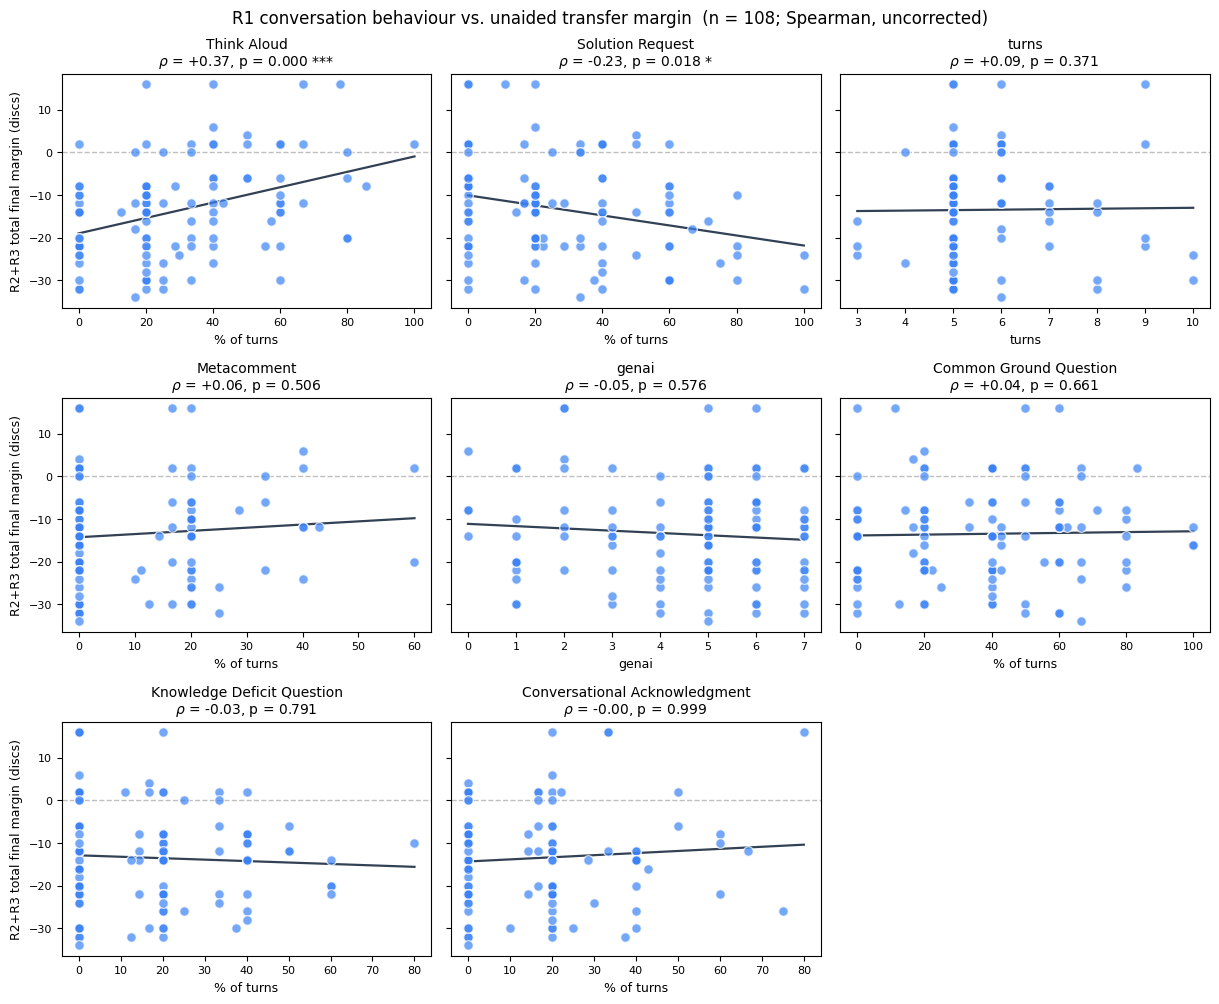

In [30]:
# --- Scatter grid: every predictor vs the summed margin ---------------------------
# One point per participant, ordered by |Spearman rho| so the strongest relationships
# read first. Line = OLS fit, drawn for the eye only.
_plot = corr.loc[corr["rho"].notna(), "predictor"].tolist()
ncol = 3
nrow = int(np.ceil(len(_plot) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.1 * ncol, 3.4 * nrow), sharey=True, squeeze=False)
for ax, v in zip(axes.ravel(), _plot):
    d = P[[v, "y"]].dropna()
    x, yv = d[v].values, d["y"].values
    rho, p = st.spearmanr(x, yv)
    ax.scatter(x, yv, s=48, c="#3b82f6", alpha=0.7, edgecolor="white", lw=1.0, zorder=3)
    if x.std() > 0:
        b, a0 = np.polyfit(x, yv, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, a0 + b * xs, color="#334155", lw=1.6, zorder=2)
    ax.axhline(0, color="0.75", lw=1, ls="--", zorder=1)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "." if p < .10 else ""
    ax.set_title(f"{v}\n$\\rho$ = {rho:+.2f}, p = {p:.3f} {star}", fontsize=10)
    ax.set_xlabel("% of turns" if v in ACTS + ["reasoning"] else v, fontsize=9)
    ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(_plot):]:
    ax.set_visible(False)
for r_ in range(nrow):
    axes[r_, 0].set_ylabel("R2+R3 total final margin (discs)", fontsize=9)
fig.suptitle(f"R1 conversation behaviour vs. unaided transfer margin  "
             f"(n = {len(P)}; Spearman, uncorrected)", fontsize=12)
plt.tight_layout(); plt.show()

## OLS

Same nested structure as the 2-group notebook's regression, with the summed margin as DV
and no group variable anywhere. `reasoning` is the focal predictor; `genai` and
`solution_req` (the % of turns carrying **Solution Request**) enter as covariates, and
`r1_margin` is the prior-skill control. The full coefficient table is printed for **every**
model, followed by the focal slopes lined up across models so their stability is readable
in one column.

**`turns` is deliberately not a covariate.** It is null against the outcome (ρ = +0.09,
p = 0.37), it failed its partial F-test, and it is the denominator of both act shares, so
including it adds a degree of freedom while asking the model to hold constant something
already baked into the predictors. It stays in the correlation screen and the scatter grid
above, where it is a descriptive result rather than an adjustment.

`solution_req` is the natural foil for `reasoning` — asking the assistant *for the move*
rather than reasoning out loud. Because both are shares of the same turns, M3 asks whether
each still predicts the margin once the other is held fixed.

Coefficients are **discs of R2+R3 margin per unit of the predictor**; shares are in
percentage points, so a slope of +0.4 means +4 discs per +10 pp of that act. `beta` is the
standardized coefficient — SD of outcome per SD of predictor, so terms on different scales
can be compared.

M4 is the most adjusted but the least trustworthy: `r1_margin` is itself downstream of the
R1 conversation, so controlling for it partials out part of the very effect being
estimated — read M4's `b_reasoning` as a lower bound.

In [31]:
SOL_ACT = "Solution Request"          # entered as a covariate; renamed for the formula API
if SOL_ACT not in P.columns:
    raise KeyError(f"{SOL_ACT!r} is not an annotated act in this run; "
                   f"available: {', '.join(ACTS)}")

# Formula API can't parse a column name with a space, so fit on a renamed copy.
M = P.rename(columns={SOL_ACT: "solution_req"})
TERMS = ["reasoning", "genai", "solution_req", "r1_margin"]     # `turns` is not a covariate

MODELS = [("M1  reasoning",                      "y ~ reasoning"),
          ("M2  + genai",                        "y ~ reasoning + genai"),
          ("M3  + genai + sol.request",          "y ~ reasoning + genai + solution_req"),
          ("M4  + genai + sol.request + R1 mgn", "y ~ reasoning + genai + solution_req + r1_margin")]


def _coef_block(lab, fit):
    """Full coefficient table for one model: coef, SE, t, p, CI, standardized beta.
    Betas use the SDs of the rows THIS model was actually fit on, so they stay
    comparable to its own coefficients when a covariate drops rows."""
    terms = [t for t in fit.params.index if t != "Intercept"]
    used = M.dropna(subset=["y"] + terms)
    sd, sdy = used[terms].std(ddof=1), used["y"].std(ddof=1)
    print(f"\n  {lab:<34} n={int(fit.nobs):<4} R2={fit.rsquared:.3f}  "
          f"adjR2={fit.rsquared_adj:.3f}  AIC={fit.aic:.1f}")
    print(f"    {'term':<14} {'coef':>8} {'SE':>6} {'t':>6} {'p':>8} {'95% CI':>19} {'beta':>7}")
    for term in fit.params.index:
        lo, hi = fit.conf_int().loc[term]
        beta = (fit.params[term] * sd[term] / sdy) if term in sd.index else np.nan
        p = fit.pvalues[term]
        star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
        print(f"    {term:<14} {fit.params[term]:+8.3f} {fit.bse[term]:6.3f} "
              f"{fit.tvalues[term]:6.2f} {p:8.4f} [{lo:+8.3f},{hi:+8.3f}] "
              f"{'      ' if np.isnan(beta) else f'{beta:+7.3f}'}{star}")


print(f"DV = R2+R3 total final margin (discs)   IV = % of R1 turns with "
      f"{' / '.join(REASONING_ACTS)}")
print(f"solution_req = % of turns with {SOL_ACT}.  `turns` is NOT a covariate here — it is")
print("null against the margin and its own denominator sits inside both act shares.")

fits = {}
for lab, formula in MODELS:
    fits[lab] = smf.ols(formula, M).fit()
    _coef_block(lab, fits[lab])

# Focal slopes side by side -- the stability check, read across models.
print("\n\n  focal predictors across models")
for focal in ("reasoning", "solution_req"):
    print(f"\n  {'model':<34} {'n':>4} {'b_' + focal:>14} {'SE':>6} {'t':>6} {'p':>8} {'95% CI':>19}")
    for lab, _ in MODELS:
        f = fits[lab]
        if focal not in f.params.index:
            continue
        lo, hi = f.conf_int().loc[focal]
        p = f.pvalues[focal]
        star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
        print(f"  {lab:<34} {int(f.nobs):>4} {f.params[focal]:+14.3f} {f.bse[focal]:6.3f} "
              f"{f.tvalues[focal]:6.2f} {p:8.4f} [{lo:+8.3f},{hi:+8.3f}]{star}")

_full = fits[MODELS[-1][0]]
print(f"\n  reasoning:    +10 pp of {'/'.join(REASONING_ACTS)} turn share = "
      f"{10 * _full.params['reasoning']:+.2f} discs of R2+R3 margin (fully adjusted)")
print(f"  solution_req: +10 pp of {SOL_ACT} turn share = "
      f"{10 * _full.params['solution_req']:+.2f} discs of R2+R3 margin (fully adjusted)")
print("  * p<0.05   . p<0.10   |  predictors from R1 (AI-assisted), DV from unassisted R2+R3")
print("  M1 is the pre-specified model; M2-M4 are exploratory. beta = standardized coefficient.")

DV = R2+R3 total final margin (discs)   IV = % of R1 turns with Think Aloud
solution_req = % of turns with Solution Request.  `turns` is NOT a covariate here — it is
null against the margin and its own denominator sits inside both act shares.

  M1  reasoning                      n=108  R2=0.141  adjR2=0.133  AIC=820.9
    term               coef     SE      t        p              95% CI    beta
    Intercept       -19.035  1.679 -11.34   0.0000 [ -22.363, -15.706]        *
    reasoning        +0.181  0.043   4.18   0.0001 [  +0.095,  +0.267]  +0.376 *

  M2  + genai                        n=108  R2=0.153  adjR2=0.137  AIC=821.5
    term               coef     SE      t        p              95% CI    beta
    Intercept       -16.399  2.764  -5.93   0.0000 [ -21.880, -10.917]        *
    reasoning        +0.183  0.043   4.23   0.0001 [  +0.097,  +0.268]  +0.380 *
    genai            -0.612  0.511  -1.20   0.2333 [  -1.625,  +0.400]  -0.108

  M3  + genai + sol.request          n=10

In [32]:
# --- Model comparison: AIC/BIC + sequential partial F-tests -------------------------
# R2 cannot rank these models. It never falls when a predictor is added, however useless
# that predictor is, and the models that include r1_margin are fit on fewer rows than the
# others (it is missing for some participants), so their R2 is not even measured against
# the same total variance. The second block fixes both by refitting every model on the
# common complete-case sample.
_common = M.dropna(subset=["y"] + TERMS)

print("as fitted -- rows DIFFER across models, so R2/AIC are not comparable in this block")
print(f"  {'model':<34} {'n':>4} {'R2':>7} {'adjR2':>7} {'AIC':>8} {'BIC':>8}")
for lab, _ in MODELS:
    f = fits[lab]
    print(f"  {lab:<34} {int(f.nobs):>4} {f.rsquared:7.3f} {f.rsquared_adj:7.3f} "
          f"{f.aic:8.1f} {f.bic:8.1f}")

cfits = {lab: smf.ols(formula, _common).fit() for lab, formula in MODELS}
_best = min(cfits, key=lambda k: cfits[k].aic)

print(f"\nrefit on the common complete-case sample (n={len(_common)}) -- comparable")
print(f"  {'model':<34} {'k':>2} {'R2':>7} {'adjR2':>7} {'AIC':>8} {'dAIC':>6} {'BIC':>8}")
for lab, _ in MODELS:
    f = cfits[lab]
    print(f"  {lab:<34} {int(f.df_model):>2} {f.rsquared:7.3f} {f.rsquared_adj:7.3f} "
          f"{f.aic:8.1f} {f.aic - cfits[_best].aic:6.1f} {f.bic:8.1f}"
          f"{'  <-- lowest AIC' if lab == _best else ''}")

print("\nsequential partial F-tests on the common sample "
      "(does each added predictor beat its own degree of freedom?)")
print(f"  {'comparison':<16} {'df':>3} {'F':>7} {'p':>8}   added")
for (l0, _), (l1, _) in zip(MODELS, MODELS[1:]):
    a = sm.stats.anova_lm(cfits[l0], cfits[l1])
    F, p = a["F"].iloc[1], a["Pr(>F)"].iloc[1]
    added = sorted(set(cfits[l1].params.index) - set(cfits[l0].params.index))
    star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
    print(f"  {l0.split()[0] + ' -> ' + l1.split()[0]:<16} {int(a['df_diff'].iloc[1]):>3} "
          f"{F:7.2f} {p:8.4f}   {', '.join(added)}{star}")

print("\n  AIC: lower is better. dAIC < 2 = indistinguishable, > 10 = decisive.")
print("  F-test p > 0.05: the added predictor explained no more than chance would.")
print("  Neither criterion validates the CAUSAL story -- they rank in-sample fit only.")

as fitted -- rows DIFFER across models, so R2/AIC are not comparable in this block
  model                                 n      R2   adjR2      AIC      BIC
  M1  reasoning                       108   0.141   0.133    820.9    826.3
  M2  + genai                         108   0.153   0.137    821.5    829.5
  M3  + genai + sol.request           108   0.181   0.157    819.9    830.6
  M4  + genai + sol.request + R1 mgn   98   0.216   0.182    741.8    754.8

refit on the common complete-case sample (n=98) -- comparable
  model                               k      R2   adjR2      AIC   dAIC      BIC
  M1  reasoning                       1   0.152   0.143    743.5    1.7    748.7
  M2  + genai                         2   0.166   0.149    743.9    2.0    751.6
  M3  + genai + sol.request           3   0.191   0.165    743.0    1.1    753.3
  M4  + genai + sol.request + R1 mgn  4   0.216   0.182    741.8    0.0    754.8  <-- lowest AIC

sequential partial F-tests on the common sample (doe

In [33]:
# --- Collinearity check ------------------------------------------------------------
# `turns` is the denominator of both act shares, and the 5-turn mandate floor-censors it,
# so these are related by construction; `reasoning` and `solution_req` also compete for
# the same turns. VIF > 5 means the individual slopes in the model above are being split
# between correlated predictors and should not be read separately.
_X = M[TERMS].dropna()
_Xc = sm.add_constant(_X)
print(f"VIF (n={len(_X)})")
for i, name in enumerate(_Xc.columns):
    if name == "const":
        continue
    v = variance_inflation_factor(_Xc.values, i)
    print(f"  {name:<14} {v:6.2f}{'   <-- inflated' if v > 5 else ''}")

print("\npairwise Spearman among predictors")
print(_X.corr(method="spearman").round(2).to_string())

VIF (n=98)
  reasoning        1.08
  genai            1.00
  solution_req     1.24
  r1_margin        1.16

pairwise Spearman among predictors
              reasoning  genai  solution_req  r1_margin
reasoning          1.00   0.04         -0.22      -0.05
genai              0.04   1.00         -0.03      -0.02
solution_req      -0.22  -0.03          1.00       0.41
r1_margin         -0.05  -0.02          0.41       1.00
